In [218]:

# 0 - import packages

import pandas as pd
import numpy as np
import pandas_datareader as pdr
import matplotlib.pyplot as plt


In [219]:
#1 Data and Data Cleaning - Importing Data

#start date for data
start_date_data = "2006-03-01"

#start and end date for later calculations
start_date_model = "2016-01-01"
end_date_model = "2026-09-17"

fred_tickers = {
    "3M":  "DGS3MO",
    "6M":  "DGS6MO",
    "1Y":  "DGS1",
    "2Y":  "DGS2",
    "3Y":  "DGS3",
    "5Y":  "DGS5",
    "7Y":  "DGS7",
    "10Y": "DGS10",
    "20Y": "DGS20",
    "30Y": "DGS30",
}

series = {}
for label, ticker in fred_tickers.items():
    series[label] = pdr.get_data_fred(ticker, start=start_date)[ticker]



In [220]:
#1 Data and Data Cleaning - Cleaning and Inspecting Data
yields = yields.ffill()
print (yields.isna().sum())
print (yields.head())
print (yields.tail())
print (yields.shape)
print (yields.describe())




3M     0
6M     0
1Y     0
2Y     0
3Y     0
5Y     0
7Y     0
10Y    0
20Y    0
30Y    0
dtype: int64
              3M    6M    1Y    2Y    3Y    5Y    7Y   10Y   20Y   30Y
DATE                                                                  
2006-03-01  4.60  4.75  4.74  4.71  4.68  4.63  4.60  4.59  4.74  4.56
2006-03-02  4.62  4.75  4.74  4.72  4.72  4.68  4.66  4.64  4.80  4.62
2006-03-03  4.62  4.75  4.75  4.76  4.75  4.71  4.69  4.68  4.84  4.66
2006-03-06  4.60  4.77  4.77  4.77  4.77  4.76  4.74  4.74  4.91  4.72
2006-03-07  4.60  4.77  4.77  4.77  4.79  4.76  4.75  4.74  4.91  4.72
              3M    6M    1Y    2Y    3Y    5Y    7Y   10Y   20Y   30Y
DATE                                                                  
2026-09-11  4.07  4.12  4.35  4.63  4.69  4.78  4.87  4.96  5.38  5.35
2026-09-14  4.11  4.18  4.37  4.65  4.73  4.80  4.88  4.97  5.37  5.34
2026-09-15  4.11  4.17  4.39  4.67  4.76  4.83  4.91  5.00  5.40  5.36
2026-09-16  4.14  4.22  4.45  4.74  4.82  4.8

In [221]:
#2 Data Transformations - yield in bps
yields_bps = yields * 100

print (yields_bps.shape)
print (yields_bps.describe())
print (yields_bps.abs().max())
print (yields_bps.abs().idxmax())



(5362, 10)
                3M           6M           1Y           2Y           3Y  \
count  5362.000000  5362.000000  5362.000000  5362.000000  5362.000000   
mean    174.021634   181.839985   185.569377   195.796904   209.238344   
std     198.365452   195.755963   186.002720   167.173813   153.488082   
min       0.000000     2.000000     4.000000     9.000000    10.000000   
25%       8.000000    14.000000    20.000000    50.000000    85.000000   
50%      52.000000    73.500000   100.500000   127.000000   151.000000   
75%     373.000000   378.000000   370.000000   361.000000   361.000000   
max     563.000000   561.000000   549.000000   529.000000   526.000000   

                5Y           7Y         10Y          20Y          30Y  
count  5362.000000  5362.000000  5362.00000  5362.000000  5362.000000  
mean    240.210183   268.693957   294.75345   343.243566   354.066393  
std     133.333389   121.167998   113.41843   111.188445   100.655235  
min      19.000000    36.000000   

In [222]:
#2 Data Transformations - Rolling Correlation Function
def rolling_cor(window_yields):

    mu = window_yields.mean()
    sigma = window_yields.std()
    correlation_matrix = window_yields.corr()

    return mu, sigma, correlation_matrix



In [223]:
#2 Data Transformations - Principal Components
def pca(correlation_matrix,  n_components =3):

    #eigendecomposition, sorting from large to small, selecting the largest three for level, slope and curvature
    eigen_values, eigen_vectors = np.linalg.eigh(correlation_matrix)
    eigen_values = np.flip(eigen_values)
    eigen_vectors = np.flip(eigen_vectors, axis=1)

    eigen_vectors = eigen_vectors[:, :n_components]
    eigen_values = eigen_values[ :n_components]

    #sign alignment
    tenors = list(correlation_matrix.columns)
    idx_2y = tenors.index('2Y')
    idx_5y = tenors.index('5Y')
    idx_10y = tenors.index('10Y')
    idx_30y = tenors.index('30Y')

    if eigen_vectors[:, 0][idx_10y] < 0:
        eigen_vectors[:, 0] = -eigen_vectors[:, 0]

    if eigen_vectors[:, 1][idx_30y] < eigen_vectors[:, 1][idx_2y]:
        eigen_vectors[:, 1] = -eigen_vectors[:, 1]

    if eigen_vectors[:, 2][idx_5y] > 0:
        eigen_vectors[:, 2] = -eigen_vectors[:, 2]

    return eigen_values, eigen_vectors






In [224]:
#3 Data Transformation - residuals
def compute_residuals (yields_bps, target_date, rolling_window_years=5, n_components=3, trading_days=252):

    #getting changes from target_date-2521 until target_date-1
    W = rolling_window_years * trading_days
    window = yields_bps.loc[:target_date].iloc[:-1].iloc[-W:]

    #getting mu, sigma and correlation matrix
    mu, sigma, correlation_matrix = rolling_cor(window)

    #eigen decomposition, keeping only largest three eigenvectors for level, slope and curvature resulting in a 10x3 eigen matrix
    eigen_values, eigen_matrix = pca(correlation_matrix = correlation_matrix, n_components = n_components)

    #getting target date changes vector
    target_vector = yields_bps.loc[target_date]

    #standardizing
    standardized_target_vector = (target_vector - mu) / sigma

    #projecting the standardized target vector onto the (10x3) eigen matrix i.e. projecting on level, slope and curvature
    #projected = (eigen_matrix @ eigen_matrix.T) @ standardized_target_vector
        #splitting it in two parts H= eigen_matrix.T @ standardized_target_vector
        #where H are the coefficients of the eigen matrix, analogue to beta in OLS projection
        #so projected = eigen_matrix @ H

    H =  eigen_matrix.T @ standardized_target_vector.values
    projected_standardized_target_vector = eigen_matrix @ H

    #destandardizing the target vector
    projected_target_vector = (projected_standardized_target_vector * sigma) + mu

    residual_vector = target_vector - projected_target_vector

    #correlation matrix columns for next function
    correlation_columns = correlation_matrix.columns

    return residual_vector, H, eigen_matrix, correlation_columns



resid_vector, H, eigen_matrix, correlation_columns = compute_residuals(yields_bps = yields_bps, target_date = '2025-01-06', rolling_window_years = 5, n_components = 3)
print (correlation_columns)




Index(['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y'], dtype='str')


In [225]:
#3 Data Transformations - getting all residuals
def compute_all_residuals(yields_bps, start_date, end_date, rolling_window_years=5, n_components=3):

    dates = yields_bps.loc[start_date:end_date].index
    residuals = []
    coefficients = []
    eigen_matrix_loadings = {}

    for d in dates:
        resid, H, eigen_matrix, correlation_columns = compute_residuals(yields_bps=yields_bps, target_date=d, rolling_window_years=rolling_window_years, n_components=n_components)
        residuals.append(resid)
        coefficients.append(H)
        eigen_matrix_loadings[d] = pd.DataFrame(eigen_matrix, index=correlation_columns, columns=['PC1','PC2','PC3'])



    residuals_df = pd.DataFrame(residuals, index=dates)
    H_df = pd.DataFrame(coefficients, index=dates, columns=['PC1','PC2','PC3'])
    return residuals_df, H_df, eigen_matrix_loadings


residuals_df, H_df, eigen_matrix_loadings = compute_all_residuals(yields_bps =yields_bps, start_date = start_date_model, end_date = end_date_model, rolling_window_years = 5, n_components = 3)



In [226]:
print (residuals_df.shape)
print (residuals_df.head())

print (H_df.shape)
print (H_df.head())

(2795, 10)
                  3M        6M        1Y        2Y        3Y        5Y  \
DATE                                                                     
2016-01-01 -3.314192  5.038975  1.829829  0.071332 -9.380769 -5.163056   
2016-01-04  0.218165  1.853618 -3.704109  0.176418  0.436866  4.087029   
2016-01-05 -1.445440  1.618479  2.232611 -1.438123 -4.226283 -1.847801   
2016-01-06 -0.553808 -0.015768  2.452101 -2.152510 -2.887503  0.208085   
2016-01-07 -0.908852  0.338115  3.123143 -2.621731 -3.791622 -0.306165   

                  7Y       10Y       20Y       30Y  
DATE                                                
2016-01-01 -1.375793 -0.137717  7.246786  6.946732  
2016-01-04  4.895177 -1.452164 -2.029246 -4.916291  
2016-01-05  0.636178 -0.925541  4.318064  2.238984  
2016-01-06  2.642609 -0.196585  1.639887 -0.410956  
2016-01-07  2.156746  0.953312  1.418014  0.434408  
(2795, 3)
                 PC1       PC2       PC3
DATE                                    
2016-01

In [227]:
#4 Signal Generation - rolling z-score and conversion into buy and sell signals

#rolling z-score
def rolling_z_score(yields_bps, window = 20):
    mu = yields_bps.rolling(window).mean()
    sigma = yields_bps.rolling(window).std()
    return (yields_bps - mu) / sigma

#generating signals per tenor, per day
def generate_signals(residuals_df, entry=2.0, exit=0.5):
    z_score = rolling_z_score(residuals_df, window = 20)
    signals = pd.DataFrame(0.0, index=z_score.index, columns=z_score.columns)

    for tenor in z_score.columns:
        pos = 0
        for t in z_score.index:
            z = z_score.loc[t, tenor]
            if pd.isna(z):
                signals.loc[t, tenor] = 0
                continue

            if pos == 0:                    # flat
                if z > entry:   pos = +1
                elif z < -entry: pos = -1
            elif pos == +1:                 # long: exit als z klein/positief genoeg
                if z < exit:    pos = 0
            elif pos == -1:                 # short: exit als z klein/negatief genoeg
                if z > -exit:   pos = 0

            signals.loc[t, tenor] = pos

    return signals

signals = generate_signals(residuals_df, entry=2, exit=0.5)

In [228]:
#5 Hedge Function - calculate weights of hedge tenors that result in no exposure to level, slope or curvature of the deviated tenor we are betting on to mean revert

def compute_hedge(eigen_vectors, target_tenor, hedge_tenors):
    loading_matrix_hedge = eigen_vectors.loc[hedge_tenors].values.T # (3,3) (loadings x hedge tenors)
    loading_vector_to_hedge = eigen_vectors.loc[target_tenor].values # (3,1)

    hedge_weights = np.linalg.solve(loading_matrix_hedge, -loading_vector_to_hedge)

    hedged_position = pd.Series(0.0, index = eigen_vectors.index)
    hedged_position.loc[target_tenor] = 1.0
    hedged_position.loc[hedge_tenors] = hedge_weights
    return hedged_position


hedge_map = {
    "2Y":  ["1Y",  "3Y",  "5Y"],
    "3Y":  ["2Y",  "5Y",  "7Y"],
    "5Y":  ["3Y",  "7Y",  "10Y"],
    "7Y":  ["5Y",  "10Y", "30Y"],
    "10Y": ["7Y",  "20Y", "30Y"],
    "20Y": ["7Y", "10Y", "30Y"],
}



Gross annualized Sharpe: 2.01
DATE
2016-01-01    0.000000
2016-01-04    0.000000
2016-01-05    0.000000
2016-01-06    0.000000
2016-01-07    0.000000
                ...   
2026-09-11    3.441988
2026-09-14    6.357768
2026-09-15    2.149436
2026-09-16   -0.915210
2026-09-17    0.277488
Length: 2795, dtype: float64
sharpe:  2.0067225619550153

Total P&L without transaction costs:
843.4


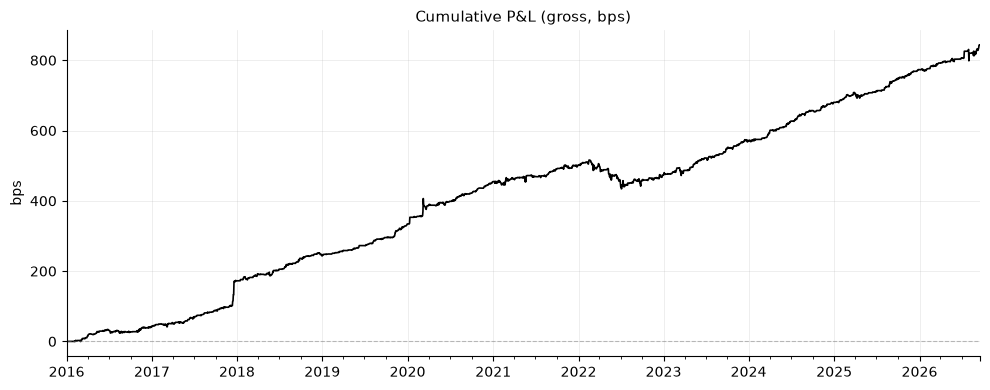

In [238]:
#6 Backtest Function

def backtest(yields_bps, signals, eigen_matrix_loadings, hedge_map):
    changes = yields_bps.diff()   # daily yield changes in bps
    pnl = pd.DataFrame(0.0, index=signals.index, columns=hedge_map.keys())

    dates = signals.index
    for target, hedge_tenors in hedge_map.items():
        for i, t in enumerate(dates[:-1]):    #until t-1, becasue we have no t+1
            sig = signals.loc[t, target]
            if sig == 0 or pd.isna(sig):
                continue

            loadings = eigen_matrix_loadings[t]
            hedge = compute_hedge(loadings, target, hedge_tenors)

            t_next = dates[i + 1]
            dy = changes.loc[t_next]
            pnl.loc[t_next, target] = -sig * (hedge @ dy)

    return pnl


return_series = pnl.sum(axis=1)
sharpe = return_series.mean() / return_series.std() * np.sqrt(252)
print(f"Gross annualized Sharpe: {sharpe:.2f}")

print (return_series)
print ("sharpe: ", sharpe)

print ("\nTotal P&L without transaction costs:")
print(return_series.sum().round(1))


#plot gross bps curve
plt.style.use('default')

fig, ax = plt.subplots(figsize=(10, 4))
pnl.cumsum().sum(axis=1).plot(ax=ax, color='black', linewidth=1.2)

ax.axhline(0, color='gray', ls='--', alpha=0.5, linewidth=0.8)
ax.set_title("Cumulative P&L (gross, bps)", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("bps")
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("cumulative_pnl.png", dpi=200, bbox_inches='tight')
plt.show()

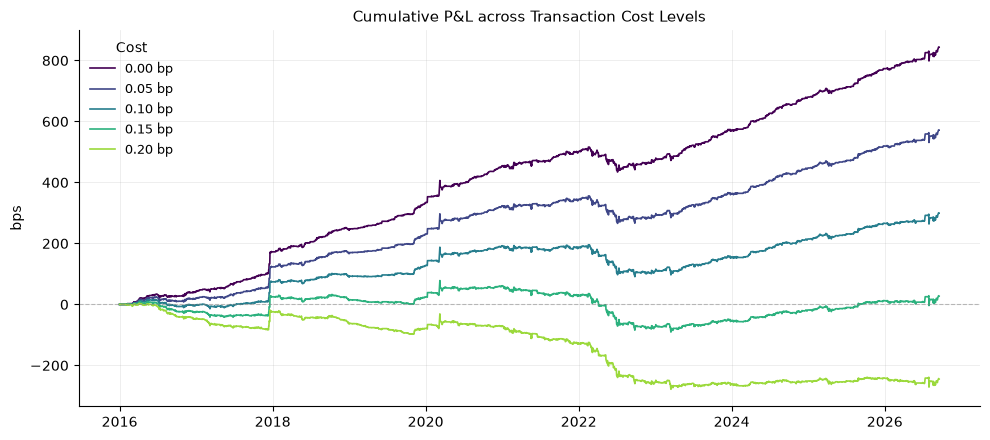


Transaction Cost Sensitivity:
               cumulative P&L (bps)  modified Sharpe
cost (bp/leg)                                       
0.00                         843.41             2.01
0.05                         571.41             1.37
0.10                         299.41             0.72
0.15                          27.41             0.07
0.20                        -244.59            -0.59


In [240]:
#7 Transaction cost analysis

plt.style.use('default')


def apply_tx_costs(pnl, signals, hedge_map, cost_per_leg=0.5):
    tx_pnl = pnl.copy()
    for target, hedge_tenors in hedge_map.items():
        trades = signals[target].diff().abs()
        cost = trades * 4 * cost_per_leg #4 positions per trade, for in and out
        tx_pnl[target] -= cost
    return tx_pnl


def modified_sharpe(daily_pnl):
    r = daily_pnl.dropna()
    return r.mean() / r.std() * np.sqrt(252)


#loop over different TX
cost_levels = [0.0, 0.05, 0.10, 0.15, 0.20]
results = {}
summary_rows = []

for c in cost_levels:
    p = apply_tx_costs(pnl, signals, hedge_map, cost_per_leg=c)
    daily = p.sum(axis=1)
    results[c] = daily
    summary_rows.append({
        "cost (bp/leg)": c,
        "cumulative P&L (bps)": daily.sum(),
        "modified Sharpe": modified_sharpe(daily),
    })

summary = pd.DataFrame(summary_rows).set_index("cost (bp/leg)")


#Plots of bps curve with different TX
fig, ax = plt.subplots(figsize=(10, 4.5))

colors = plt.cm.viridis(np.linspace(0, 0.85, len(cost_levels)))

for (c, daily), color in zip(results.items(), colors):
    ax.plot(daily.cumsum(), label=f"{c:.2f} bp", color=color, linewidth=1.2)

ax.axhline(0, color="gray", ls="--", alpha=0.5, linewidth=0.8)
ax.set_title("Cumulative P&L across Transaction Cost Levels", fontsize=11)
ax.set_ylabel("bps")
ax.set_xlabel("")
ax.legend(title="Cost", loc="upper left", frameon=False, fontsize=9)
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("pnl_tx_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()



print("\nTransaction Cost Sensitivity:")
print(summary.round(2).to_string())